# 1. Data Loading
Load the H&M datasets and set consistent ID types for joins.

In [23]:
from pathlib import Path
import pandas as pd
import gzip
import pickle
from PIL import Image
import matplotlib.pyplot as plt
import networkx as nx
import random

In [11]:
DATA_DIR = Path("..") / "data" / "raw" / "hnm"
ARTICLES_PATH = DATA_DIR / "articles.csv"
CUSTOMERS_PATH = DATA_DIR / "customers.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions_train.csv"

# Ensure IDs are strings for safe joins
articles = pd.read_csv(ARTICLES_PATH, dtype={"article_id": "string"})
customers = pd.read_csv(CUSTOMERS_PATH, dtype={"customer_id": "string"})
transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    dtype={"customer_id": "string", "article_id": "string"},
    parse_dates=["t_dat"],
)

print("articles:", articles.shape)
print("customers:", customers.shape)
print("transactions:", transactions.shape)

articles: (105542, 25)
customers: (1371980, 7)
transactions: (31788324, 5)


# 2. Top–Bottom Filtering
Filter articles into tops and bottoms using the confirmed `product_type_name` lists, then restrict transactions accordingly.

In [2]:
TOP_TYPES = [
    "T-shirt",
    "Top",
    "Blouse",
    "Shirt",
    "Sweater",
    "Hoodie",
    "Cardigan",
    "Vest top",
    "Jacket",
    "Blazer",
]

BOTTOM_TYPES = [
    "Trousers",
    "Shorts",
    "Skirt",
    "Leggings/Tights",
    "Underwear bottom",
    "Swimwear bottom",
]

tops_df = articles[articles["product_type_name"].isin(TOP_TYPES)].copy()
bottoms_df = articles[articles["product_type_name"].isin(BOTTOM_TYPES)].copy()

top_ids = set(tops_df["article_id"])
bottom_ids = set(bottoms_df["article_id"])
allowed_ids = top_ids.union(bottom_ids)

transactions_tb = transactions[transactions["article_id"].isin(allowed_ids)].copy()
customers_retained = transactions_tb["customer_id"].nunique()

print("tops:", len(tops_df))
print("bottoms:", len(bottoms_df))
print("filtered transactions:", len(transactions_tb))
print("customers retained:", customers_retained)

tops: 40692
bottoms: 23737
filtered transactions: 21399702
customers retained: 1255775


# 3. Context-Based Item Filtering
Use segment, occasion, and optional season to narrow candidate tops and bottoms.

In [8]:
segment = "Menswear"
occasion = "Casual"
season = "Winter"  # Options: "Winter", "Summer", "All-season"

segment_tops = tops_df[tops_df["index_group_name"] == segment].copy()
segment_bottoms = bottoms_df[bottoms_df["index_group_name"] == segment].copy()

def show_top_values(df, col, n=10):
    if col not in df.columns:
        print(f"{col}: column not found")
        return
    print(f"{col} top {n}:")
    print(df[col].value_counts(dropna=False).head(n))
    print()

show_top_values(segment_tops, "product_group_name")
show_top_values(segment_tops, "department_name")
show_top_values(segment_tops, "section_name")

show_top_values(segment_bottoms, "product_group_name")
show_top_values(segment_bottoms, "department_name")
show_top_values(segment_bottoms, "section_name")

product_group_name top 10:
product_group_name
Garment Upper body    6390
Name: count, dtype: int64

department_name top 10:
department_name
Jersey Fancy               1478
Shirt                      1152
Knitwear                   1085
Light Basic Jersey          408
Basics                      219
Jersey inactive from s1     210
Jacket Casual               197
Projects                    168
Heavy Basic Jersey          166
Jacket Smart                163
Name: count, dtype: int64

section_name top 10:
section_name
Contemporary Smart       1259
Contemporary Street      1100
Contemporary Casual      1064
Men Suits & Tailoring     972
Men Underwear             936
Mens Outerwear            514
Men Edition               213
Men Project               212
Men Other 2               116
Men Other                   4
Name: count, dtype: int64

product_group_name top 10:
product_group_name
Garment Lower body    2464
Underwear              387
Swimwear               245
Name: count, dtype: int64

In [9]:
# Occasion rules based on the provided example. Update if you want different mappings.
OCCASION_RULES = {
    "Casual": {
        "tops": ["T-shirt", "Hoodie", "Sweater", "Top", "Cardigan"],
        "bottoms": ["Trousers", "Shorts", "Skirt", "Leggings/Tights"],
    },
    "Formal": {
        "tops": ["Shirt", "Blazer"],
        "bottoms": ["Trousers"],
    },
    "Sport": {
        "tops": ["Top", "T-shirt"],
        "bottoms": ["Leggings/Tights", "Shorts", "Swimwear bottom"],
    },
}

SEASON_RULES = {
    "Winter": {
        "tops": ["Sweater", "Hoodie", "Jacket", "Cardigan"],
        "bottoms": ["Trousers", "Leggings/Tights"],
    },
    "Summer": {
        "tops": ["T-shirt", "Top", "Vest top"],
        "bottoms": ["Shorts", "Skirt", "Swimwear bottom"],
    },
    "All-season": {"tops": [], "bottoms": []},
}

def filter_by_occasion(df, occasion, rules, kind):
    if not rules or occasion not in rules:
        return df.copy()
    allowed = rules[occasion].get(kind, [])
    if not allowed:
        return df.copy()
    return df[df["product_type_name"].isin(allowed)].copy()

def filter_by_season(df, season, rules, kind):
    if not season or season not in rules:
        return df.copy()
    allowed = rules[season].get(kind, [])
    if not allowed:
        return df.copy()
    return df[df["product_type_name"].isin(allowed)].copy()

filtered_tops = filter_by_occasion(segment_tops, occasion, OCCASION_RULES, "tops")
filtered_bottoms = filter_by_occasion(segment_bottoms, occasion, OCCASION_RULES, "bottoms")

filtered_tops = filter_by_season(filtered_tops, season, SEASON_RULES, "tops")
filtered_bottoms = filter_by_season(filtered_bottoms, season, SEASON_RULES, "bottoms")

print("filtered tops:", len(filtered_tops))
print("filtered bottoms:", len(filtered_bottoms))

filtered tops: 2356
filtered bottoms: 1756


# 4. Graph Construction
Build a top–bottom co-occurrence graph from filtered transactions with segment-safe pairing.

In [5]:
from collections import Counter, defaultdict

# Build a global graph from all top/bottom transactions (context-agnostic)
top_ids = set(tops_df["article_id"])
bottom_ids = set(bottoms_df["article_id"])

tx_filtered = transactions_tb.copy()

# Precompute item -> segment for safe pairing
segment_by_id = articles.set_index("article_id")["index_group_name"].to_dict()

cooccurrence = Counter()
top_to_bottoms = defaultdict(Counter)

for customer_id, group in tx_filtered.groupby("customer_id"):
    item_ids = group["article_id"].unique().tolist()
    tops_in_tx = [i for i in item_ids if i in top_ids]
    bottoms_in_tx = [i for i in item_ids if i in bottom_ids]
    if not tops_in_tx or not bottoms_in_tx:
        continue
    for top_id in tops_in_tx:
        for bottom_id in bottoms_in_tx:
            if segment_by_id.get(top_id) != segment_by_id.get(bottom_id):
                continue
            cooccurrence[(top_id, bottom_id)] += 1
            top_to_bottoms[top_id][bottom_id] += 1

def get_top_bottom_candidates(top_id, k=100):
    if top_id not in top_to_bottoms:
        return []
    return [b for b, _ in top_to_bottoms[top_id].most_common(k)]

neighbor_counts = [len(c) for c in top_to_bottoms.values()]
tops_with_10 = sum(1 for n in neighbor_counts if n >= 10)
avg_neighbors = sum(neighbor_counts) / len(neighbor_counts) if neighbor_counts else 0

print("tops with >=10 bottoms:", tops_with_10)
print("avg bottoms per top:", round(avg_neighbors, 2))

tops with >=10 bottoms: 37074
avg bottoms per top: 854.76


In [ ]:
top_bottom_cooccurrence_graph_path = Path("../data/processed/top_bottom_cooccurrence_graph.pkl.gz")

# Ensure directory exists
top_bottom_cooccurrence_graph_path.parent.mkdir(parents=True, exist_ok=True)

# Save graph
with gzip.open(top_bottom_cooccurrence_graph_path, "wb") as f:
    pickle.dump(top_to_bottoms, f)

print("Graph saved to:", top_bottom_cooccurrence_graph_path)
print("Total tops stored:", len(top_to_bottoms))

Graph saved to: ..\data\processed\top_bottom_cooccurrence_graph.pkl.gz
Total tops stored: 39665


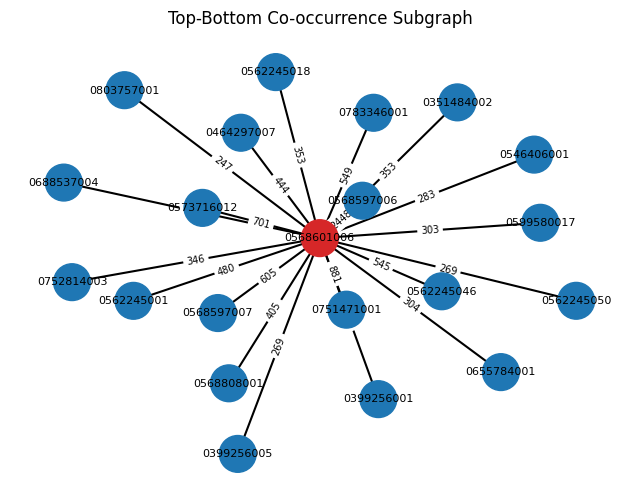

In [17]:
top_bottom_cooccurrence_graph_path = Path("../data/processed/top_bottom_cooccurrence_graph.pkl.gz")
with gzip.open(top_bottom_cooccurrence_graph_path, "rb") as f:
    top_to_bottoms = pickle.load(f)

test_top_id = list(top_to_bottoms.keys())[0]
top_neighbors = top_to_bottoms[test_top_id].most_common(20)

G = nx.Graph()
G.add_node(test_top_id, node_type="top")
for bottom_id, weight in top_neighbors:
    G.add_node(bottom_id, node_type="bottom")
    G.add_edge(test_top_id, bottom_id, weight=weight)

pos = nx.spring_layout(G, seed=42)
node_colors = ["#d62728" if G.nodes[n].get("node_type") == "top" else "#1f77b4" for n in G.nodes]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, width=1.5)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Top-Bottom Co-occurrence Subgraph")
plt.axis("off")
plt.show()

In [20]:
filtered_bottom_ids = set(filtered_bottoms["article_id"])

outfit_candidates = []

top_ids_to_test = filtered_tops["article_id"].head(5).tolist()
for top_id in top_ids_to_test:
    candidates = get_top_bottom_candidates(top_id, k=20)
    candidates = [b for b in candidates if b in filtered_bottom_ids]
    print(f"Top: {top_id}")
    print(f"Recommended bottoms: {candidates}")
    print()
    for bottom_id in candidates:
        outfit_candidates.append((top_id, bottom_id))

print("Total outfit candidates:", len(outfit_candidates))

Top: 0176209023
Recommended bottoms: ['0720504001', '0397068001', '0441386001', '0397068015', '0397068014', '0751994001', '0636207005', '0763988001', '0664647001', '0720504008', '0720504004', '0636207006', '0441386004', '0721390001', '0730863018']

Top: 0176209025
Recommended bottoms: ['0569978001', '0721390001', '0636586001', '0397068015', '0397068014', '0397068001', '0411758001', '0721390005', '0720504001', '0685815001', '0664647001', '0569978016']

Top: 0176209033
Recommended bottoms: ['0843465004', '0734512001', '0720504008', '0449897048']

Top: 0176209035
Recommended bottoms: ['0397068012', '0636207005', '0730863027', '0732188002', '0730863012', '0784245002', '0664647001', '0801166003', '0458428033', '0441386004', '0118458003', '0397068015']

Top: 0176209039
Recommended bottoms: ['0664647003', '0397068001', '0720504001', '0397068015', '0720504008', '0397068014', '0611020005', '0636207006', '0449897001', '0720504007', '0720504004', '0400342003']

Total outfit candidates: 55


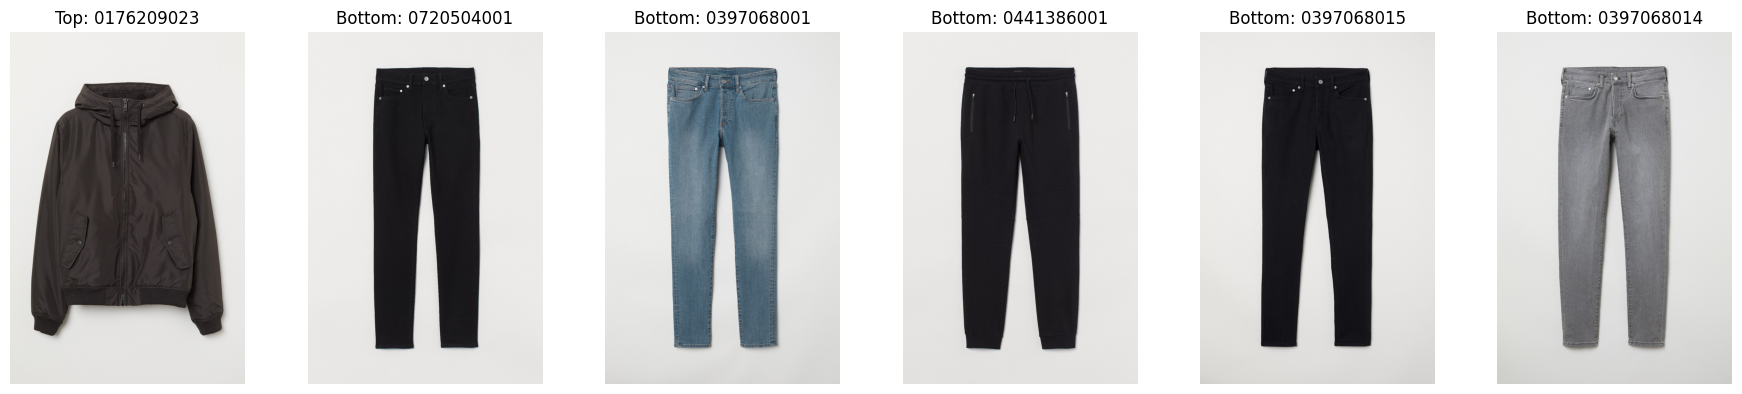

In [21]:
IMAGE_BASE = Path("../data/raw/hnm/images")

def get_image_path(article_id):
    article_str = str(article_id)
    folder = article_str[:3]
    return IMAGE_BASE / folder / f"{article_str}.jpg"

def show_outfit(top_id, bottom_ids):
    top_path = get_image_path(top_id)
    top_img = Image.open(top_path) if top_path.exists() else None

    bottom_imgs = []
    for bottom_id in bottom_ids:
        bottom_path = get_image_path(bottom_id)
        if bottom_path.exists():
            bottom_imgs.append(Image.open(bottom_path))
        else:
            bottom_imgs.append(None)

    total = 1 + len(bottom_ids)
    fig, axes = plt.subplots(1, total, figsize=(3 * total, 4))
    if total == 1:
        axes = [axes]

    if top_img is not None:
        axes[0].imshow(top_img)
    axes[0].set_title(f"Top: {top_id}")
    axes[0].axis("off")

    for i, (bottom_id, img) in enumerate(zip(bottom_ids, bottom_imgs), start=1):
        if img is not None:
            axes[i].imshow(img)
        axes[i].set_title(f"Bottom: {bottom_id}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

top_id = "0176209023"
bottom_ids = [
    "0720504001", "0397068001", "0441386001",
    "0397068015", "0397068014",
]
show_outfit(top_id, bottom_ids)

# 5. Generate Initial GA Population
Create initial population of outfit chromosomes [top_id, bottom_id] using graph-based candidate generation.

In [24]:
POPULATION_SIZE = 100
CANDIDATES_PER_TOP = 50

def generate_initial_population(tops_df, filtered_bottoms, top_to_bottoms, size=POPULATION_SIZE):
    """Generate initial population of outfit chromosomes."""
    population = []
    filtered_bottom_ids = set(filtered_bottoms["article_id"])
    top_ids_list = tops_df["article_id"].tolist()
    
    attempts = 0
    max_attempts = size * 10
    
    while len(population) < size and attempts < max_attempts:
        attempts += 1
        top_id = random.choice(top_ids_list)
        
        # Get graph candidates and filter by context
        candidates = get_top_bottom_candidates(top_id, k=CANDIDATES_PER_TOP)
        candidates = [b for b in candidates if b in filtered_bottom_ids]
        
        if not candidates:
            continue
        
        bottom_id = random.choice(candidates)
        chromosome = [top_id, bottom_id]
        
        # Avoid duplicates
        if chromosome not in population:
            population.append(chromosome)
    
    return population

initial_population = generate_initial_population(
    filtered_tops, filtered_bottoms, top_to_bottoms, size=POPULATION_SIZE
)

print(f"Generated population size: {len(initial_population)}")
print(f"Sample chromosomes:")
for i, chrom in enumerate(initial_population[:5]):
    print(f"  {i+1}. Top: {chrom[0]}, Bottom: {chrom[1]}")

Generated population size: 100
Sample chromosomes:
  1. Top: 0551790003, Bottom: 0441386004
  2. Top: 0551790005, Bottom: 0714032002
  3. Top: 0574150002, Bottom: 0636207006
  4. Top: 0730610002, Bottom: 0720504001
  5. Top: 0687707002, Bottom: 0664647004


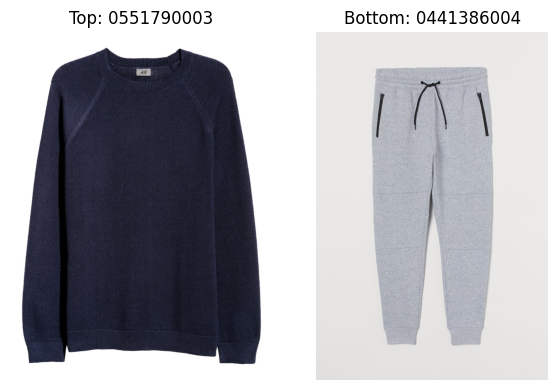

In [26]:
show_outfit("0551790003", ["0441386004"])

# 6. Genetic Algorithm for Outfit Optimization
Implement fitness function and GA operators to evolve the best top–bottom outfit pairs.

In [29]:
# User preferences for color-based scoring
user_preferences = {
    "preferred_colors": ["Black", "Grey"],
    "avoid_colors": ["Yellow"]
}

# Precompute article color mapping
article_color = articles.set_index("article_id")["colour_group_name"].to_dict()

print("User preferences:", user_preferences)

User preferences: {'preferred_colors': ['Black', 'Grey'], 'avoid_colors': ['Yellow']}


In [30]:
def fitness(chromosome, top_to_bottoms, cooccurrence, user_preferences):
    """Calculate fitness score for an outfit chromosome."""
    top_id, bottom_id = chromosome
    
    # --- Graph compatibility ---
    graph_score = cooccurrence.get((top_id, bottom_id), 0)
    max_score = max(cooccurrence.values()) if cooccurrence else 1
    graph_score = graph_score / max_score if max_score > 0 else 0
    
    # --- Color preference score ---
    top_color = article_color.get(top_id, "")
    bottom_color = article_color.get(bottom_id, "")
    
    color_score = 0.5  # neutral base
    
    if top_color in user_preferences["preferred_colors"]:
        color_score += 0.25
    if bottom_color in user_preferences["preferred_colors"]:
        color_score += 0.25
    
    if top_color in user_preferences["avoid_colors"]:
        color_score -= 0.25
    if bottom_color in user_preferences["avoid_colors"]:
        color_score -= 0.25
    
    color_score = max(0, min(1, color_score))
    
    # --- Final fitness ---
    return 0.7 * graph_score + 0.3 * color_score

def tournament_selection(population, fitnesses, k=3):
    """Select one chromosome using tournament selection."""
    tournament_indices = random.sample(range(len(population)), k)
    tournament_fitnesses = [fitnesses[i] for i in tournament_indices]
    winner_idx = tournament_indices[tournament_fitnesses.index(max(tournament_fitnesses))]
    return population[winner_idx]

def crossover(parent1, parent2):
    """Swap bottoms between two parent chromosomes."""
    child1 = [parent1[0], parent2[1]]
    child2 = [parent2[0], parent1[1]]
    return child1, child2

def mutate(chromosome, filtered_tops, filtered_bottoms, top_to_bottoms, mutation_rate=0.1):
    """Mutate chromosome by replacing bottom with a new candidate."""
    if random.random() > mutation_rate:
        return chromosome
    
    top_id = chromosome[0]
    filtered_bottom_ids = set(filtered_bottoms["article_id"])
    candidates = get_top_bottom_candidates(top_id, k=CANDIDATES_PER_TOP)
    candidates = [b for b in candidates if b in filtered_bottom_ids]
    
    if candidates:
        new_bottom = random.choice(candidates)
        return [top_id, new_bottom]
    return chromosome

print("GA functions defined.")

GA functions defined.


In [31]:
GENERATIONS = 20
CROSSOVER_RATE = 0.7
MUTATION_RATE = 0.15

def run_ga(initial_population, filtered_tops, filtered_bottoms, top_to_bottoms, cooccurrence, user_preferences, generations=GENERATIONS):
    """Run genetic algorithm to optimize outfit population."""
    population = [chrom[:] for chrom in initial_population]
    
    for gen in range(generations):
        # Evaluate fitness
        fitnesses = [
            fitness(chrom, top_to_bottoms, cooccurrence, user_preferences)
            for chrom in population
        ]
        
        # Track best
        best_idx = fitnesses.index(max(fitnesses))
        best_chrom = population[best_idx]
        best_fitness = fitnesses[best_idx]
        
        if gen % 5 == 0:
            print(f"Generation {gen}: Best fitness = {best_fitness:.4f}")
        
        # Create next generation
        new_population = []
        
        # Elitism: keep top 10%
        elite_count = max(1, int(0.1 * len(population)))
        elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:elite_count]
        new_population.extend([population[i][:] for i in elite_indices])
        
        # Generate offspring
        while len(new_population) < len(population):
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            
            if random.random() < CROSSOVER_RATE:
                child1, child2 = crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]
            
            child1 = mutate(child1, filtered_tops, filtered_bottoms, top_to_bottoms, MUTATION_RATE)
            child2 = mutate(child2, filtered_tops, filtered_bottoms, top_to_bottoms, MUTATION_RATE)
            
            new_population.extend([child1, child2])
        
        population = new_population[:len(initial_population)]
    
    # Final evaluation
    fitnesses = [
        fitness(chrom, top_to_bottoms, cooccurrence, user_preferences)
        for chrom in population
    ]
    sorted_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)
    
    return [(population[i], fitnesses[i]) for i in sorted_indices]

final_results = run_ga(
    initial_population, filtered_tops, filtered_bottoms,
    top_to_bottoms, cooccurrence, user_preferences, generations=GENERATIONS
)

print("\nTop 5 outfits:")
for i, (chrom, fit) in enumerate(final_results[:5], 1):
    print(f"{i}. Top: {chrom[0]}, Bottom: {chrom[1]}, Fitness: {fit:.4f}")

Generation 0: Best fitness = 0.3036
Generation 5: Best fitness = 0.3090
Generation 10: Best fitness = 0.3090
Generation 15: Best fitness = 0.3090

Top 5 outfits:
1. Top: 0461327001, Bottom: 0720504001, Fitness: 0.3090
2. Top: 0461327001, Bottom: 0720504001, Fitness: 0.3090
3. Top: 0461327001, Bottom: 0720504001, Fitness: 0.3090
4. Top: 0461327001, Bottom: 0720504001, Fitness: 0.3090
5. Top: 0461327001, Bottom: 0720504001, Fitness: 0.3090


# 7. Outfit Visualization
Display the top recommended outfit pairs with product images.

Visualizing top 20 unique recommended outfits:


Outfit 1 (Fitness: 0.3090)
Top: 0461327001, Bottom: 0720504001


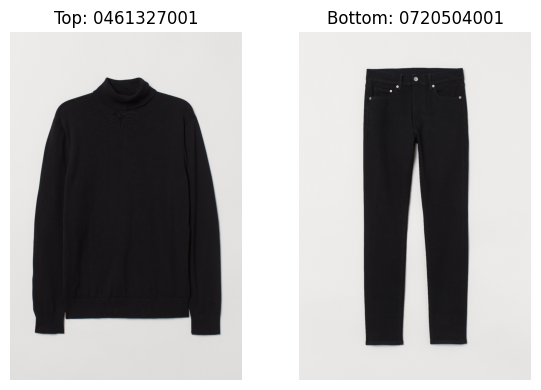


Outfit 2 (Fitness: 0.3069)
Top: 0461327001, Bottom: 0540768002


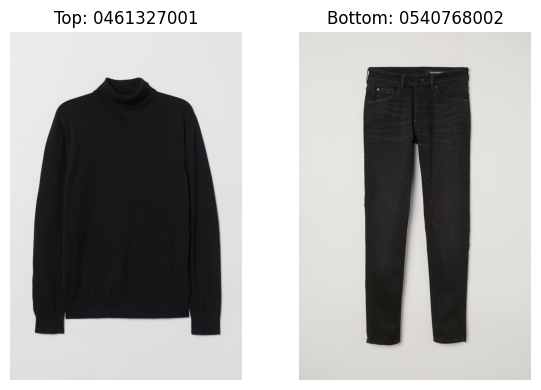


Outfit 3 (Fitness: 0.3040)
Top: 0461327001, Bottom: 0730863018


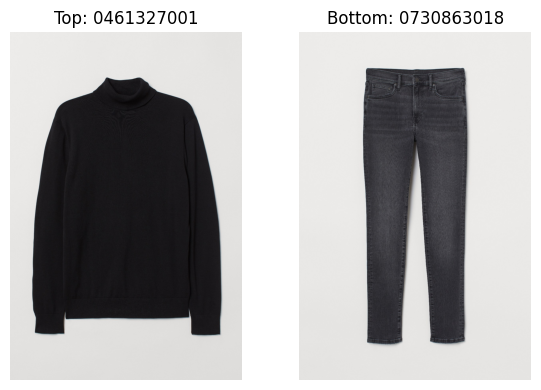


Outfit 4 (Fitness: 0.3036)
Top: 0461327001, Bottom: 0664647004


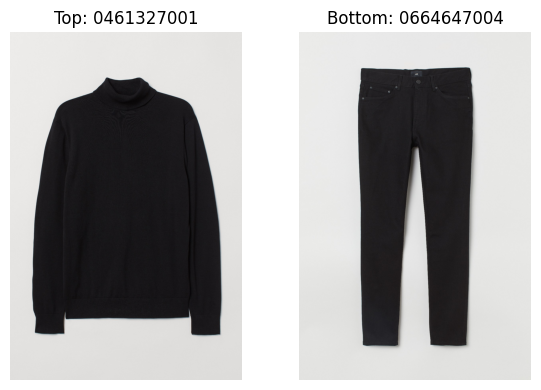


Outfit 5 (Fitness: 0.3036)
Top: 0461327001, Bottom: 0581178001


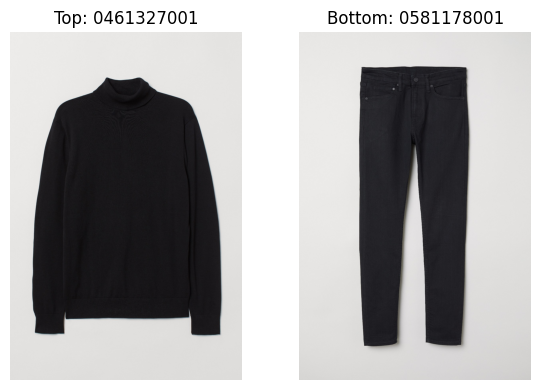


Outfit 6 (Fitness: 0.3031)
Top: 0461327001, Bottom: 0730863014


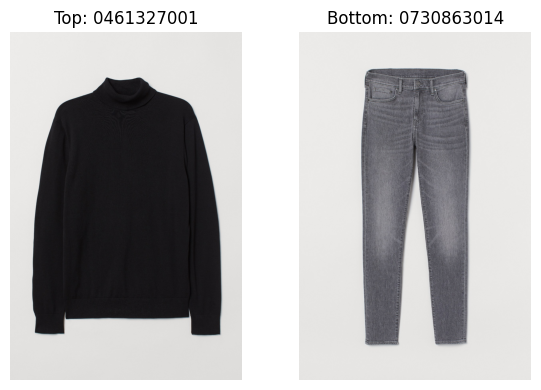


Outfit 7 (Fitness: 0.3026)
Top: 0461327001, Bottom: 0441386001


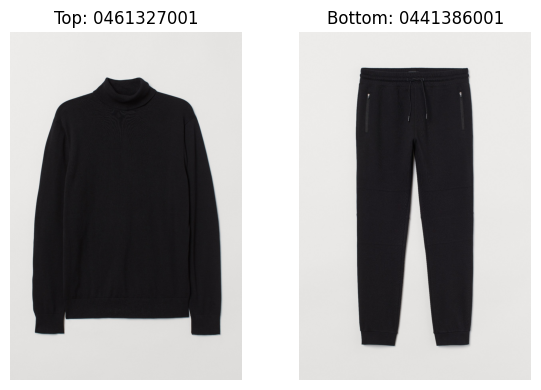


Outfit 8 (Fitness: 0.2295)
Top: 0461327001, Bottom: 0730863005


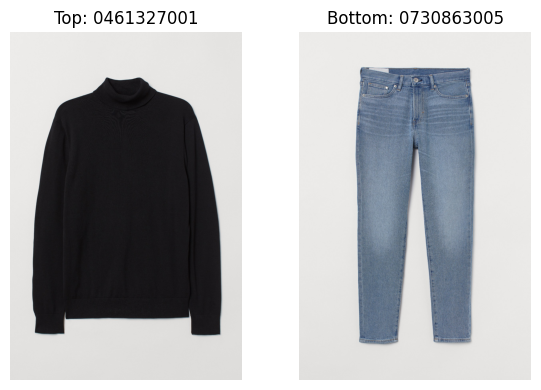


Outfit 9 (Fitness: 0.2283)
Top: 0461327001, Bottom: 0720504007


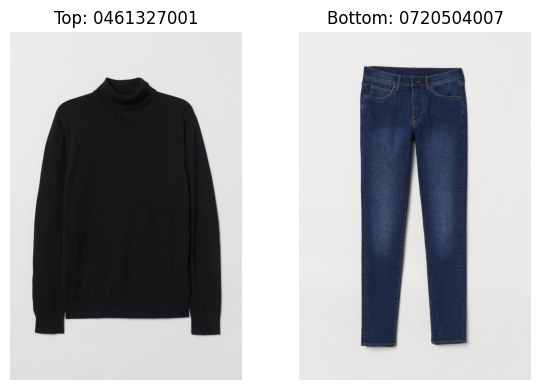


Outfit 10 (Fitness: 0.2276)
Top: 0461327001, Bottom: 0751994006


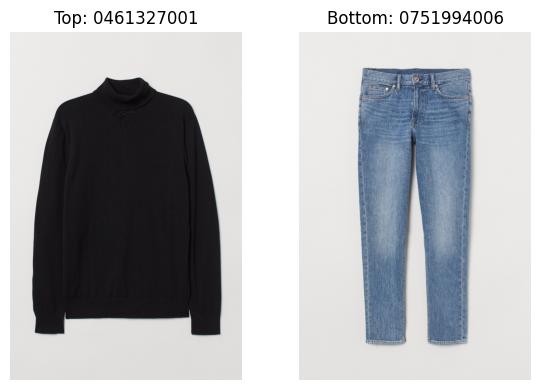


Outfit 11 (Fitness: 0.2274)
Top: 0461327001, Bottom: 0397068001


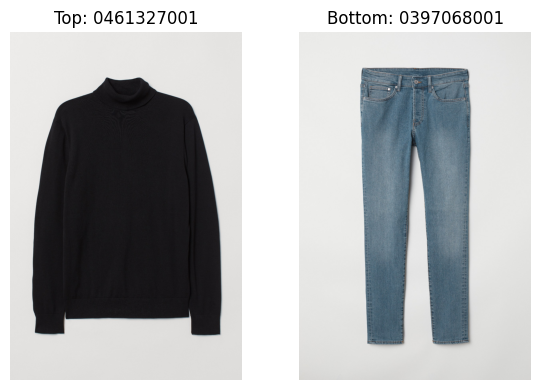

In [46]:
NUM_OUTFITS_TO_SHOW = 20

print(f"Visualizing top {NUM_OUTFITS_TO_SHOW} unique recommended outfits:\n")

seen = set()
shown = 0

for chrom, fit in final_results:
    key = tuple(chrom)
    
    if key in seen:
        continue
    
    seen.add(key)
    top_id, bottom_id = chrom
    
    print(f"\nOutfit {shown+1} (Fitness: {fit:.4f})")
    print(f"Top: {top_id}, Bottom: {bottom_id}")
    show_outfit(top_id, [bottom_id])
    
    shown += 1
    if shown == NUM_OUTFITS_TO_SHOW:
        break